In [ ]:
from model_xray.zenml.zenml_lookup import get_pp_imgs_dataset_by_name
from model_xray.configs.models import *

X,y,meta = get_pp_imgs_dataset_by_name('torch_pretrained_models', return_meta=True)

X_pp = X
X_pp = X_pp.reshape(X_pp.shape[0], -1)

## Meta DF

In [71]:
import pandas as pd
import numpy as np

def extract_xs(meta):
    meta_xs = [x.embed_payload_config for x in meta]
    meta_xs = np.array([0 if x == ret_na_val() else x.embed_proc_config.x for x in meta_xs])

    return meta_xs

def extract_model_names(meta):
    meta_model_names = [x.cover_data_config.cover_data_cfg.name for x in meta]

    return meta_model_names

meta_xs = extract_xs(meta)
meta_model_names = extract_model_names(meta)

df = pd.DataFrame({'x': meta_xs, 'model': meta_model_names, 'y': y})
df.reset_index(drop=False, inplace=True)
df.head(3)

,index,x,model,y
0,0,20,efficientnet_b3,1
1,1,18,regnet_y_16gf,1
2,2,12,regnet_y_800mf,1


### Splits

#### X & Arch

In [95]:
import math
import numpy as np

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import tqdm

from joblib import Parallel, delayed

def exp(df, X, y, train_size = 0.6, n_jobs=1):
    xs_amount = 23

    if n_jobs == 1:
        dfs = []
        for train_x in range(1, xs_amount+1):
            df_scores = exp_single(train_x, train_size)
            dfs.append(df_scores)

    else:
        dfs = Parallel(n_jobs=n_jobs)(delayed(exp_single)(df, X, y, train_x, train_size) for train_x in range(1, xs_amount+1))

    df_scores = pd.concat(dfs)
    return df_scores

def exp_single(df, X, y, train_x, train_size = 0.6, run_num=0):
    model_names = df['model'].unique()

    train_size_n = math.floor(train_size * len(model_names))

    train_model_names = np.random.choice(model_names, size=train_size_n, replace=False)
    test_model_names = np.setdiff1d(model_names, train_model_names)

    train_boolmask = ((df['model'].isin(train_model_names)) & (df['x'].isin([0, train_x])))
    train_idxs = df[train_boolmask]['index']

    X_train = X[train_idxs, ...]
    y_train = y[train_idxs]

    pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC())])
    pipe.fit(X_train, y_train)

    # print(f'train score={pipe.score(X_train, y_train)}')
    train_score = pipe.score(X_train, y_train)
    # test_scores = [None] * 24
    scores = [(train_score, 'train', train_x)]

    for x in range(0, 24):
        test_idxs = df[((df['model'].isin(test_model_names)) & (df['x'] == x))]['index']
        
        X_test = X[test_idxs, ...]
        y_test = y[test_idxs]

        # print(f'x={x}, score={pipe.score(X_test, y_test)}')
        # test_scores[x] = pipe.score(X_test, y_test)
        scores.append((pipe.score(X_test, y_test), 'test', x))

    df_scores = pd.DataFrame(scores, columns=['score', 'type', 'x'])
    df_scores['run'] = run_num
    df_scores['train_x'] = train_x

    return df_scores

run_amount = 10

def exp_parallel(
    df, X, y, train_size = 0.6, n_jobs=16, run_amount=10
):
    xs_amount = 23
    dfs = Parallel(n_jobs=n_jobs)(delayed(exp_single)(df, X, y, train_x, train_size, run) for train_x in range(1, xs_amount+1) for run in range(run_amount))

    df_scores = pd.concat(dfs)
    return df_scores

df_scores = exp_parallel(df=df, X=X_pp, y=y, n_jobs=-1, run_amount=run_amount)

# dfs = []

# for i in tqdm.tqdm(range(run_amount)):
#     df_scores = exp(df=df, X=X_pp, y=y, n_jobs=23)
#     df_scores['run'] = i
#     dfs.append(df_scores)

#     # print(f'run={i}, train_score={train_score}, test_scores={test_scores}')

# df_scores = pd.concat(dfs)
# df_scores

# test_boolmask = ((df['model'].isin(test_model_names)))
# test_idxs = df[test_boolmask]['index']

In [96]:
df_scores

,score,type,x,run,train_x
0,0.520833,train,1,0,1
1,0.250000,test,0,0,1
2,0.750000,test,1,0,1
3,0.750000,test,2,0,1
4,0.781250,test,3,0,1
...,...,...,...,...,...
20,0.000000,test,19,9,23
21,0.000000,test,20,9,23
22,0.000000,test,21,9,23
23,0.062500,test,22,9,23


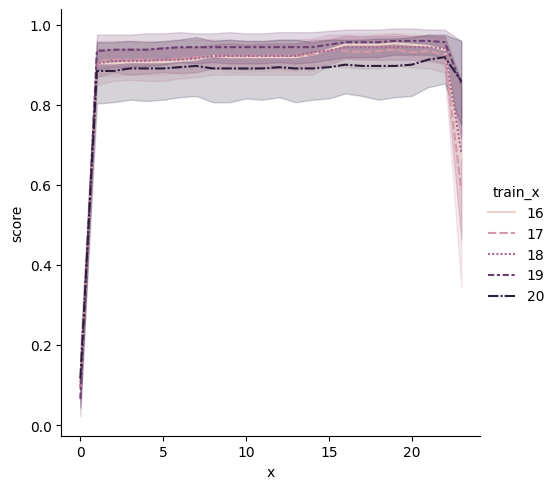

In [102]:
df_scores_test = df_scores[df_scores['type'] == 'test']

xs = range(16,21)
df_scores_test = df_scores_test[df_scores_test['train_x'].isin(xs)].sort_values(by='train_x', ascending=True)

import seaborn as sns

sns.relplot(
    data=df_scores_test, 
    x='x',
    y='score',
    kind='line',

    hue='train_x',
    style='train_x',
)

## Regular Split

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_pp, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC())])
pipe.fit(X_train, y_train).score(X_test, y_test)

0.9583333333333334

## Split By Xs

In [60]:
import numpy as np

xs_amount = 24

Xs = [None] * xs_amount
ys = [None] * xs_amount

meta_xs = [x.embed_payload_config for x in meta]
meta_xs = np.array([0 if x == ret_na_val() else x.embed_proc_config.x for x in meta_xs])

for i in range(0, xs_amount):
    Xs[i] = X_pp[meta_xs == i]
    ys[i] = y[meta_xs == i]

In [64]:
train_x = 23
X_train = np.concatenate([Xs[0], Xs[train_x]])
y_train = np.concatenate([ys[0], ys[train_x]])

In [65]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# pipe = Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())])
pipe = Pipeline([('clf', KNeighborsClassifier())])
pipe.fit(X_train, y_train).score(X_train, y_train)

0.99375

In [34]:
for i in range(0, xs_amount):
    if i == train_x:
        continue
    
    X_test = Xs[i]
    y_test = ys[i]
    print(i, pipe.score(X_test, y_test))

0 0.4625
1 0.55
2 0.5
3 0.5125
4 0.525
5 0.5125
6 0.5125
7 0.5125
9 0.6125
10 0.5875
11 0.55
12 0.575
13 0.5875
14 0.4125
15 0.575
16 0.575
17 0.525
18 0.5
19 0.5875
20 0.5375
21 0.575
22 0.55
23 0.25


## Split by Architecture

In [68]:
meta_model_names = [x.cover_data_config.cover_data_cfg.name for x in meta]
print(meta_model_names)

['efficientnet_b3', 'regnet_y_16gf', 'regnet_y_800mf', 'resnext101_64x4d', 'convnext_large', 'regnet_x_32gf', 'densenet169', 'convnext_small', 'vgg13', 'googlenet', 'mnasnet1_0', 'regnet_x_1_6gf', 'vgg13', 'regnet_y_1_6gf', 'convnext_small', 'googlenet', 'resnet101', 'regnet_y_32gf', 'resnet50', 'efficientnet_b6', 'squeezenet1_1', 'regnet_y_3_2gf', 'vgg16_bn', 'vit_h_14', 'mnasnet0_5', 'regnet_x_400mf', 'mnasnet1_3', 'inception_v3', 'regnet_y_8gf', 'regnet_y_3_2gf', 'mobilenet_v2', 'regnet_x_400mf', 'regnet_x_8gf', 'swin_v2_b', 'efficientnet_b5', 'resnext101_32x8d', 'shufflenet_v2_x1_0', 'vit_l_16', 'regnet_y_128gf', 'vit_b_32', 'swin_v2_b', 'wide_resnet101_2', 'shufflenet_v2_x1_5', 'mnasnet1_3', 'regnet_y_8gf', 'efficientnet_v2_m', 'convnext_tiny', 'vgg13_bn', 'swin_v2_b', 'googlenet', 'squeezenet1_1', 'shufflenet_v2_x0_5', 'regnet_y_8gf', 'efficientnet_b5', 'regnet_y_16gf', 'regnet_y_128gf', 'wide_resnet50_2', 'regnet_y_8gf', 'efficientnet_b5', 'shufflenet_v2_x1_5', 'wide_resnet101_2

## Visalize

In [55]:
import numpy as np
from PIL import Image
from copy import deepcopy

pp_img_lineage = meta[0]

chosen_x = 23

pp_img_lineage_benign = deepcopy(pp_img_lineage.model_dump())
pp_img_lineage_benign['embed_payload_config'] = ret_na_val()
pp_img_lineage_benign = PreprocessedImageLineage.model_validate(pp_img_lineage_benign)

pp_img_lineage_mal = deepcopy(pp_img_lineage)
pp_img_lineage_mal.embed_payload_config.embed_proc_config.x = chosen_x

benign_idx = meta.index(pp_img_lineage_benign)
mal_idx = meta.index(pp_img_lineage_mal)

benign = X[benign_idx, ...]
malicious = X[mal_idx, ...]

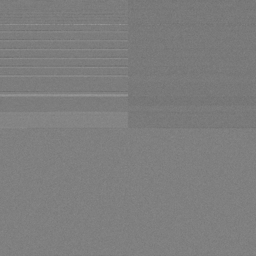

In [56]:
Image.fromarray(benign)

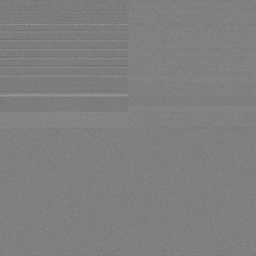

In [57]:
Image.fromarray(malicious)